In [1]:
# import packages
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, ToTensor, Resize
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import skimage as ski
import glob
import cv2
import zipfile

In [2]:
# get package versions
print('pytorch version is {}'.format(torch.__version__))
print('numpy version is {}'.format(np.__version__))
print('pandas version is {}'.format(pd.__version__))
print('matplotlib version is {}'.format(matplotlib.__version__))
print('opencv version is {}'.format(cv2.__version__))
print('scikit-image version is {}'.format(ski.__version__))

pytorch version is 2.9.0+cpu
numpy version is 2.0.2
pandas version is 2.2.2
matplotlib version is 3.10.0
opencv version is 4.13.0
scikit-image version is 0.25.2


In [3]:
# connect to mydrive
from google.colab import drive, userdata
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
# add folder to project path
proj_path= userdata.get('cnn_folder')

if proj_path not in sys.path:
  sys.path.append(proj_path)

from model_folder.model_autoenc import autoencoder
from model_folder.dataset1 import custom_dataset

In [5]:
# define device
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# create instance of model
model= autoencoder()

# load weights from pretrained model
pretrain_model= torch.load(userdata.get('save_path'), map_location= 'cpu')
model.load_state_dict(pretrain_model)



<All keys matched successfully>

custom dataset to return normalized saturation channel.

In [6]:
# define image transform
img_transform= Compose([ToTensor(), Resize((224, 224))])

In [7]:
# extract test healthy images
zip1= userdata.get('zip_folder')

with zipfile.ZipFile(zip1, 'r') as zip2:
  zip2.extractall()

In [8]:
test_healthy_dir= userdata.get('test_healthy')

# make dataset with healthy test images
test_healthy_data= custom_dataset(img_dir= test_healthy_dir, num_img= 1300, transform= img_transform)

batch1= 25

# make dataloader from dataset
test_healthy_dataloader= DataLoader(test_healthy_data, batch_size= batch1, shuffle= True)

# check size of dataset and dataloader
for i in test_healthy_data:
  print(i.shape)
  break

for j in test_healthy_dataloader:
  print(j.shape)
  break

torch.Size([1, 224, 224])
torch.Size([25, 1, 224, 224])


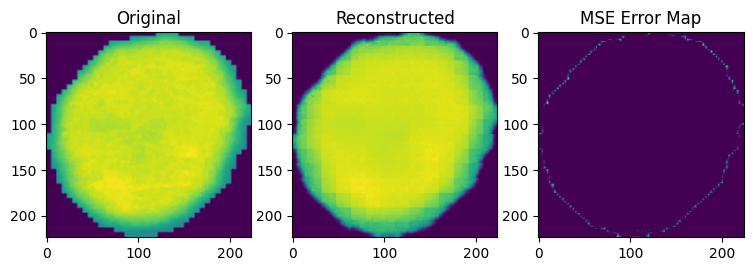

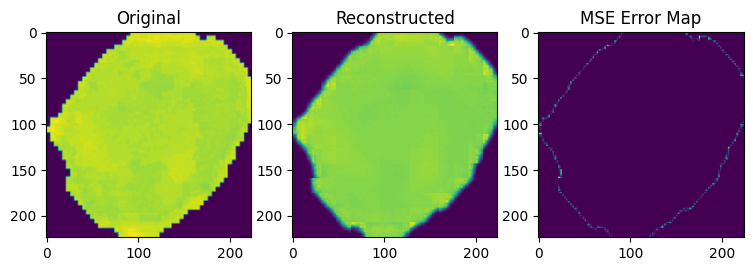

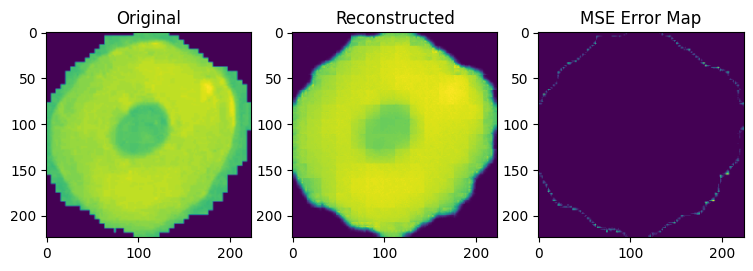

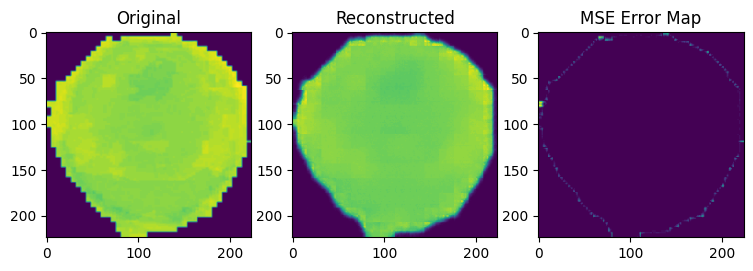

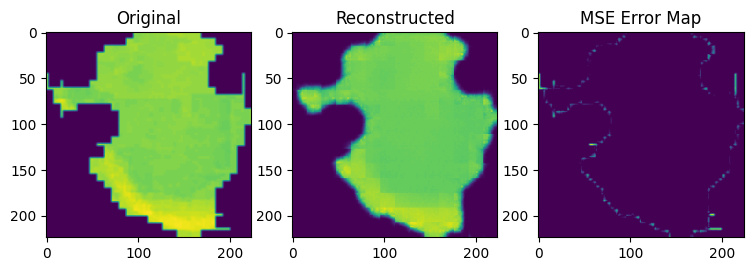

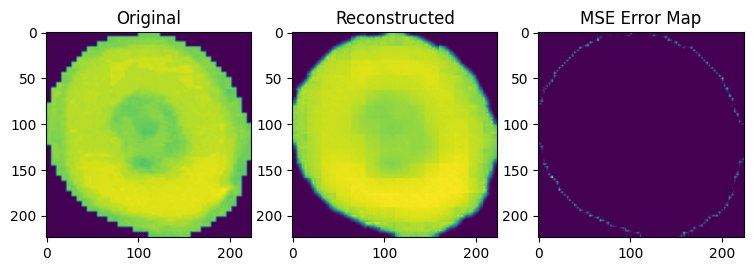

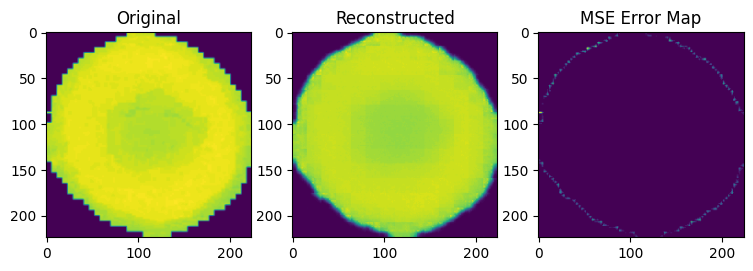

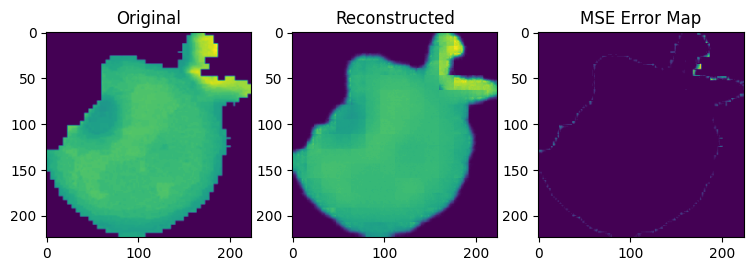

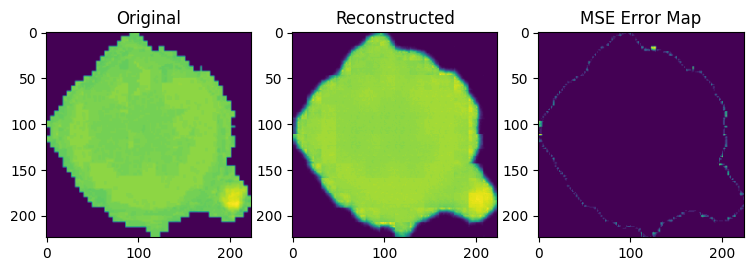

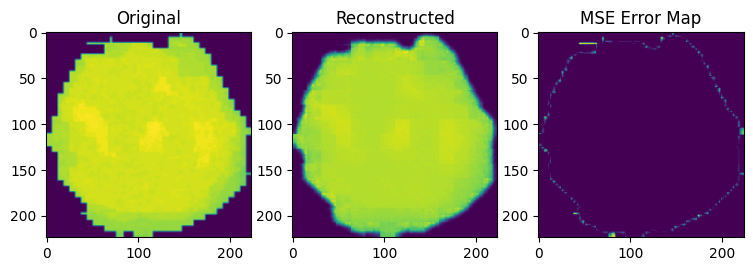

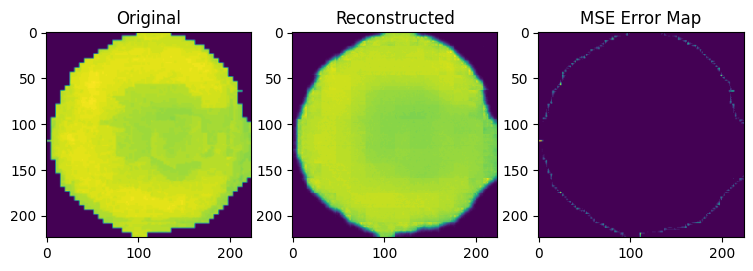

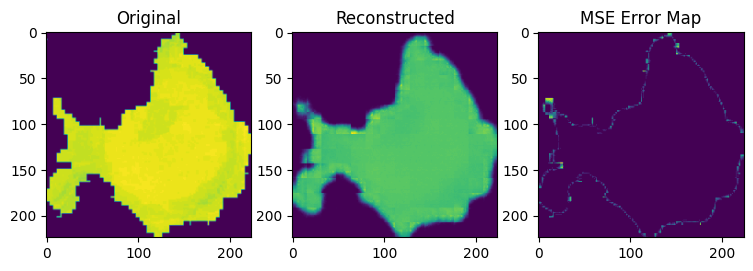

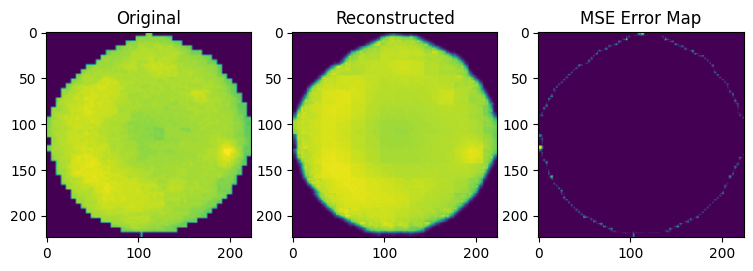

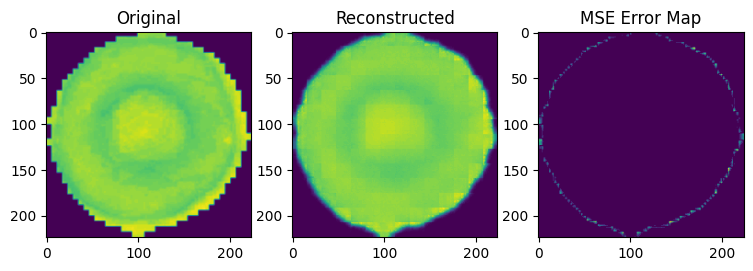

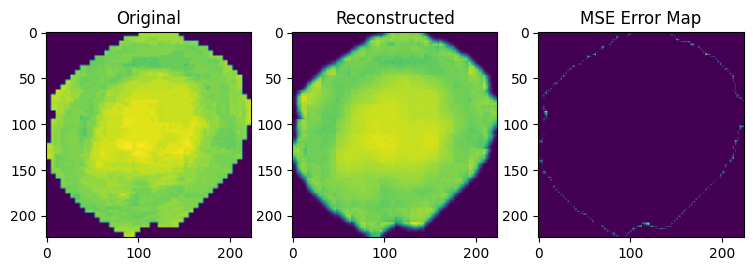

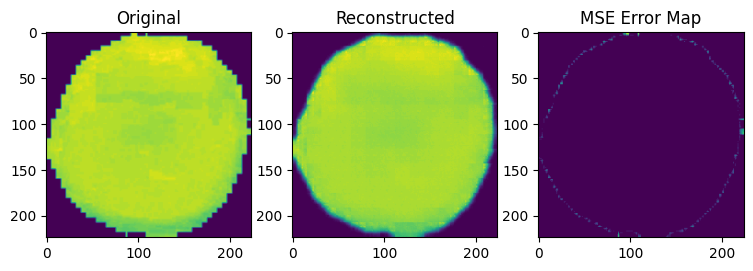

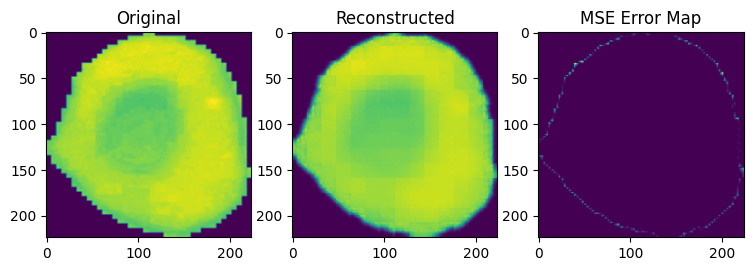

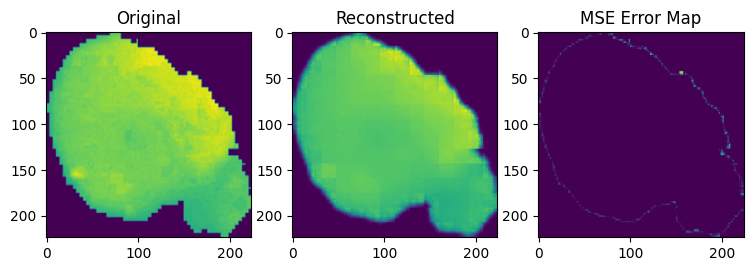

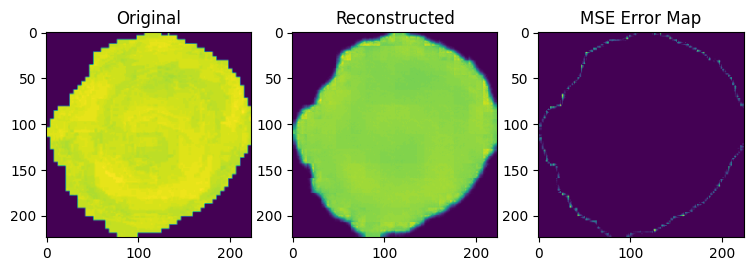

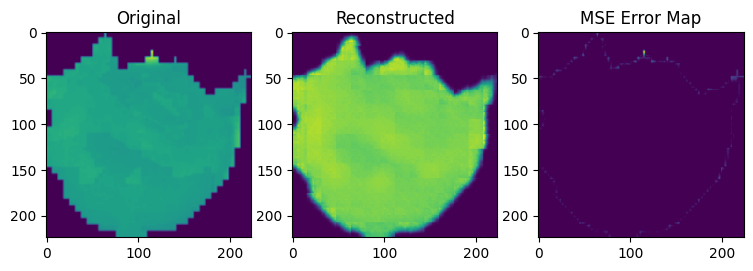

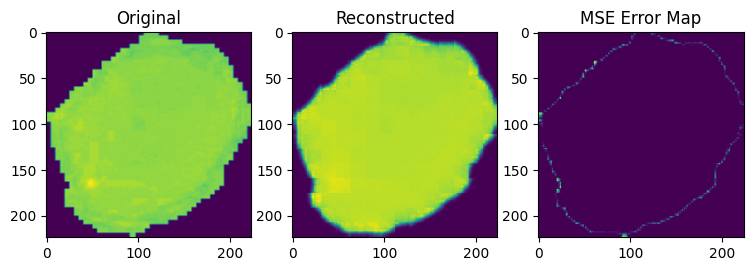

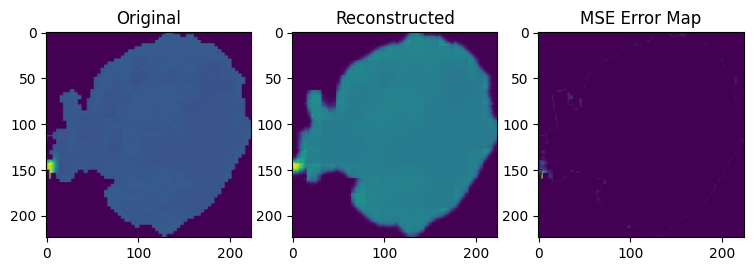

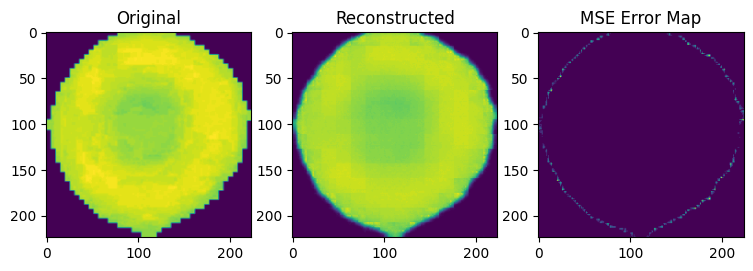

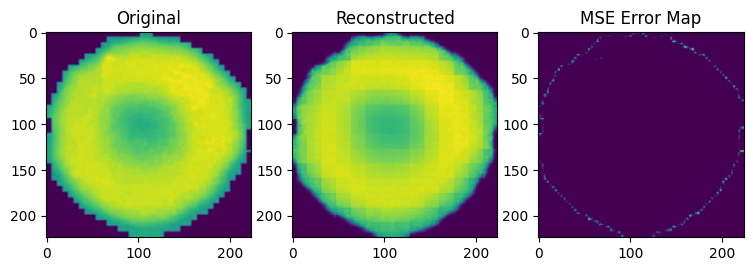

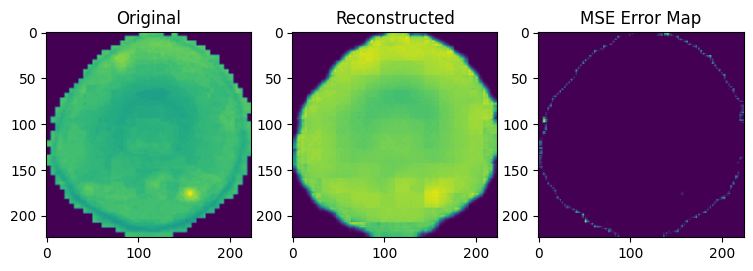

In [9]:
#look at first batch for healthy red blood cells

model.eval()

with torch.no_grad():
  # loop through dataloader
  for i in test_healthy_dataloader:
    # loop through batch
    for j in range(batch1):

      # convert from torch tensor to numpy array
      array0= i[j].numpy().transpose(1, 2, 0)
      img0= array0 * 255.0
      img0= img0.astype(np.uint8)


      # use model to reconstruct image and convert to numpy array
      array_recon= model(i[j]).numpy().transpose(1, 2, 0)
      recon_img= array_recon * 255.0
      recon_img= recon_img.astype(np.uint8)


      # calculate mse error over saturation channel
      mse_array= ((array0 - array_recon)**2).mean(axis= 2)
      # scale from 0 to 255 and convert to uint8 type
      mse_img= mse_array * 255.0
      mse_img= mse_img.astype(np.uint8)


      # visualize original, reconstructed and mse error map for first batch
      fig1, ax1= plt.subplots(1, 3, figsize= (9, 3))
      ax1[0].imshow(img0)
      ax1[0].set_title('Original')
      ax1[1].imshow(recon_img)
      ax1[1].set_title('Reconstructed')
      ax1[2].imshow(mse_img)
      ax1[2].set_title('MSE Error Map')
      plt.show(fig1)
      plt.close(fig1)
    break


MSE error map of healthy malaria red blood cells is mostly featureless.  For most images, the boundary of the red blood cell has high error.

In [10]:
# make dataset and dataloader for malaria red blood cells
test_sick_dir= userdata.get('test_sick')

# make dataset with clean test images
test_sick_data= custom_dataset(img_dir= test_sick_dir, num_img= 1300, transform= img_transform)

# make dataloader from dataset
test_sick_dataloader= DataLoader(test_sick_data, batch_size= batch1, shuffle= True)


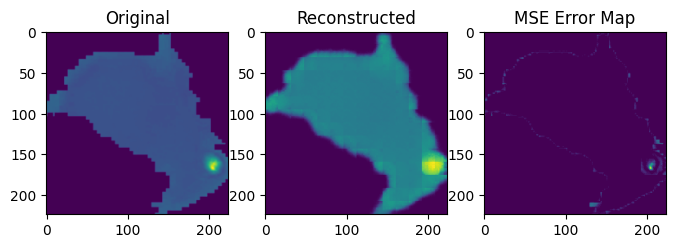

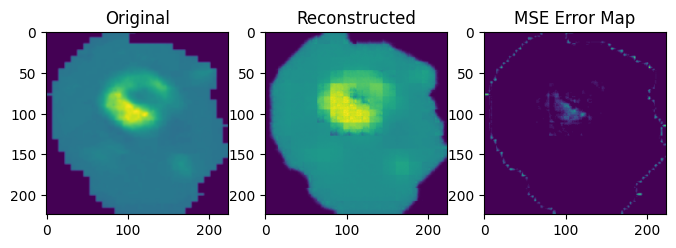

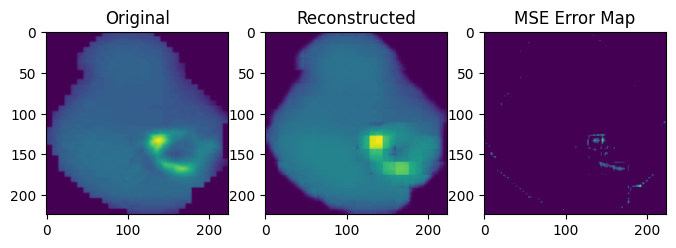

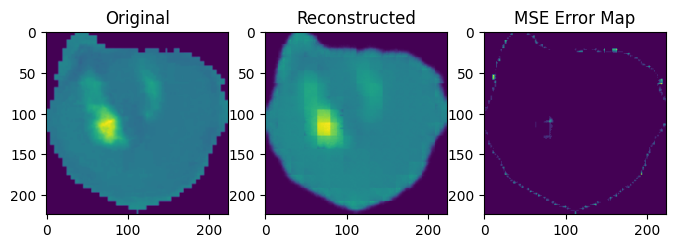

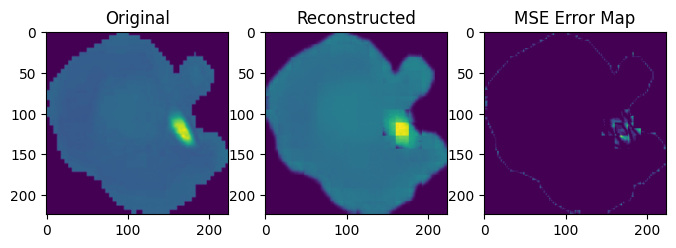

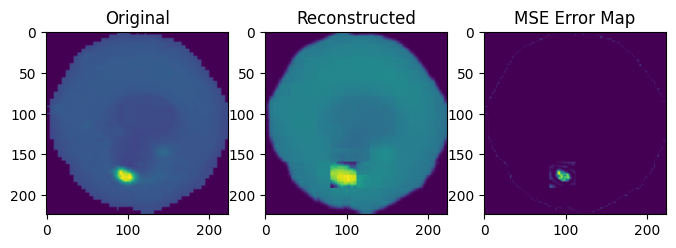

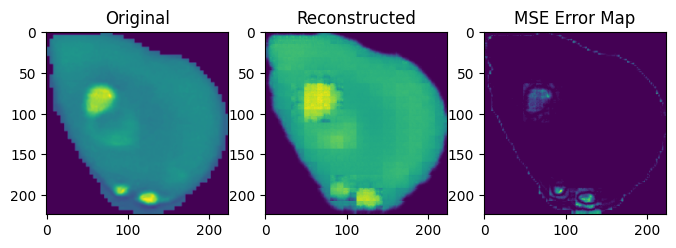

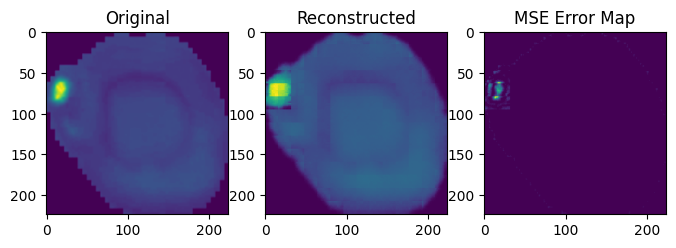

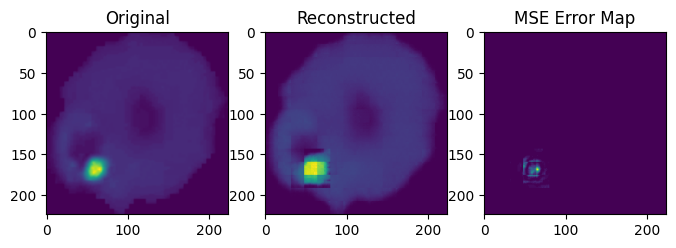

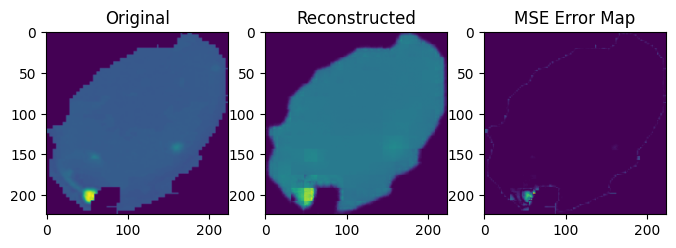

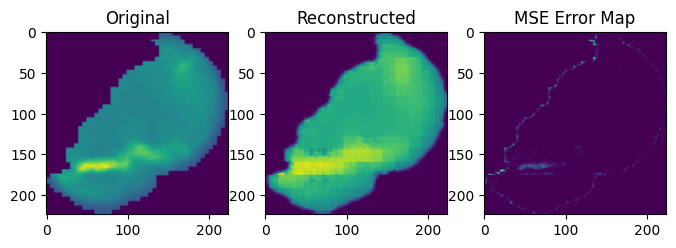

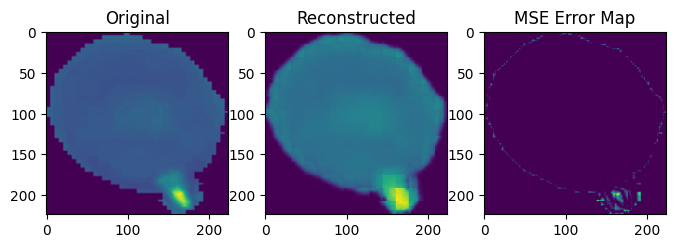

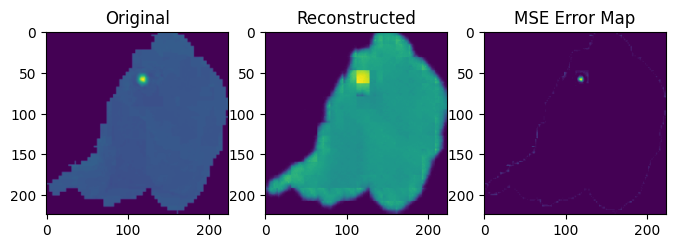

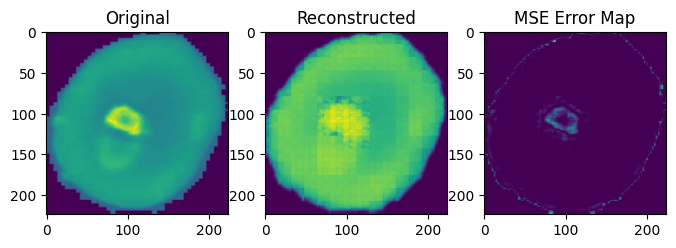

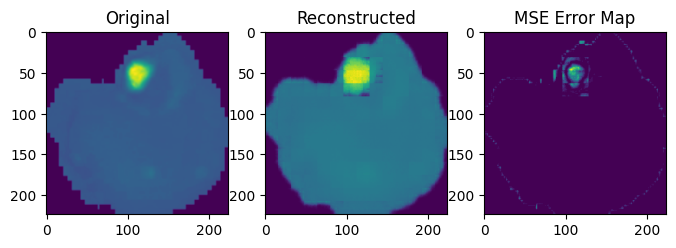

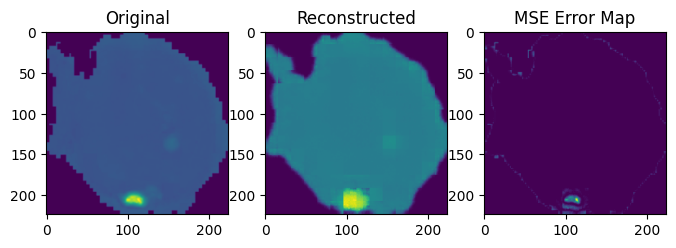

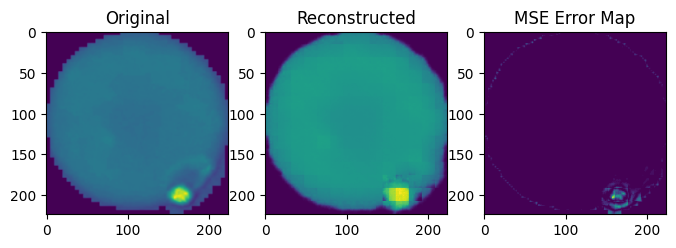

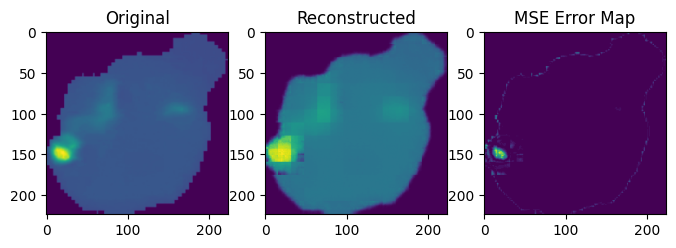

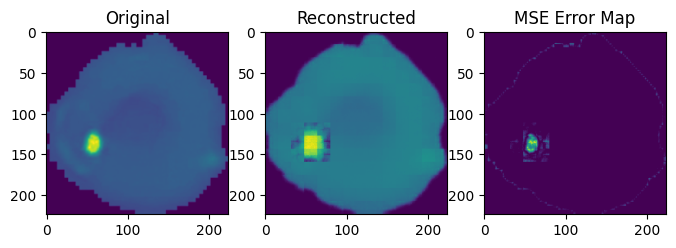

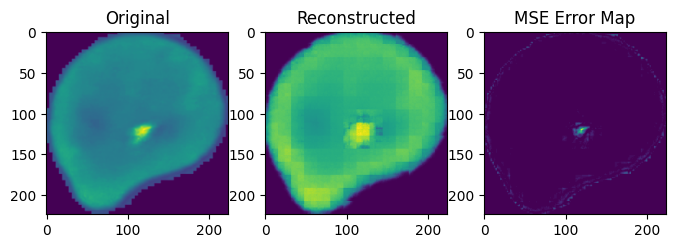

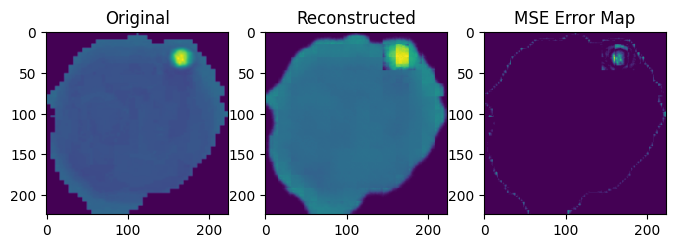

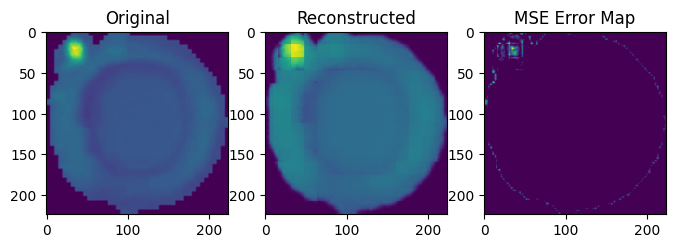

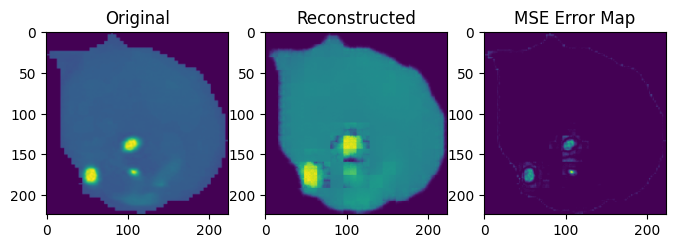

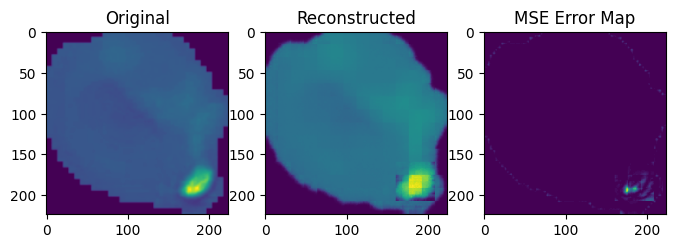

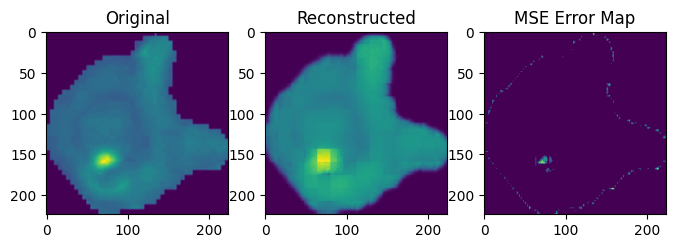

In [11]:
# look at model output for first batch of malaria red blood cells


model.eval()

with torch.no_grad():
  # loop through dataloader
  for i in test_sick_dataloader:
    # loop through batch
    for j in range(batch1):
      # convert from torch tensor to numpy array
      array0_sick= i[j].numpy().transpose(1, 2, 0)
      img0_sick= array0_sick * 255.0
      img0_sick= img0_sick.astype(np.uint8)

      # use model to reconstruc image and convert to numpy array
      array_recon_sick= model(i[j]).numpy().transpose(1, 2, 0)
      recon_img_sick= array_recon_sick * 255.0
      recon_img_sick= recon_img_sick.astype(np.uint8)

      # calculate mse error over saturation channel
      mse_array_sick= ((array0_sick - array_recon_sick)**2).mean(axis= 2)
      mse_img_sick= mse_array_sick * 255.0
      mse_img_sick= mse_img_sick.astype(np.uint8)


      # visualize original, reconstructed and mse error map
      fig2, ax2= plt.subplots(1, 3, figsize= (8, 4))
      ax2[0].imshow(img0_sick)
      ax2[0].set_title('Original')
      ax2[1].imshow(recon_img_sick)
      ax2[1].set_title('Reconstructed')
      ax2[2].imshow(mse_img_sick)
      ax2[2].set_title('MSE Error Map')
      plt.show(fig2)
      plt.close(fig2)
    break

The malaria regions in red blood cells are the dark spots/areas.  The dark spot was highlighted the most for saturation channel, that's why model was trained with only saturation channel.  Most MSE error maps seem to have higher error at the dark spot.  This CNN autoencoder, at least qualitatively, seems to detect malaria.

In [12]:
# apply image processing to malaria images and count images above limit

sick_error_list= []
sick_count= []
limit1= 20
sick_above_limit= []
count1= 1

kernel3= np.ones((3, 3), np.uint8)
kernel5= np.ones((5, 5), np.uint8)

model.eval()
with torch.no_grad():
  # loop through dataloader
  for i in test_sick_dataloader:
    # loop through batch
    for j in range(batch1):
      # original
      sick_original= i[j].numpy().transpose(1, 2, 0)
      # reconstructed
      sick_recon= model(i[j]).numpy().transpose(1, 2, 0)
      # MSE
      sick_array= ((sick_original - sick_recon)**2).mean(axis= 2)
      sick_error_list.append(sick_array)
      # image processing to remove artifacts-------------------------------------
      # make boolean mask- global threshold
      bi_0pt004= sick_array > 0.004
      # apply image opening
      open5= ski.morphology.opening(bi_0pt004, footprint= kernel5)
      # erosion
      erode3= ski.morphology.erosion(open5, footprint= kernel3)
      # remove small objects
      open5_erode3_r30= ski.morphology.remove_small_objects(erode3, min_size= 30)

      # sum everything in processed image
      sick_sum= np.sum(open5_erode3_r30)
      sick_count.append(sick_sum)
      if sick_sum > limit1:
        sick_above_limit.append(sick_sum)

      # advance counter
      count1= count1 + 1
      if count1 % 100 == 0:
        print('So far {} images done'.format(count1))

sick_correct= 100 * (len(sick_above_limit) / len(sick_error_list))

print('percent of sick images correctly identified are: {}'.format(round(sick_correct, 2)))

So far 100 images done
So far 200 images done
So far 300 images done
So far 400 images done
So far 500 images done
So far 600 images done
So far 700 images done
So far 800 images done
So far 900 images done
So far 1000 images done
So far 1100 images done
So far 1200 images done
So far 1300 images done
percent of sick images correctly identified are: 95.38


Malaria cells have bright spot that was observed clearly in hsv images specifically the saturation channel.  The bright spot is still visible in the MSE error maps even after image processing- threshold, opening, erosion and removing small objects.  Since the bright spot is still visible the malaria cells should have larger sum than healthy cells, and malaria cells should be above the limit= 20.  > 95% of malaria cells were correctly identified.  Sample size was 1300 test images.

In [13]:
# apply image processing to healthy images and count images below limit

healthy_error_list= []
healthy_count= []
healthy_below_limit= []
count1= 1


kernel3= np.ones((3, 3), np.uint8)
kernel5= np.ones((5, 5), np.uint8)

model.eval()
with torch.no_grad():
  # loop through dataloader
  for i in test_healthy_dataloader:
    # loop through batch
    for j in range(batch1):
      # original image
      healthy_original= i[j].numpy().transpose(1, 2, 0)
      # reconstructed image
      healthy_recon= model(i[j]).numpy().transpose(1, 2, 0)
      # MSE
      healthy_array= ((healthy_original - healthy_recon)**2).mean(axis= 2)
      healthy_error_list.append(healthy_array)
      # same image processing as above cell-----------------------------------------
      # make boolean mask
      bi_0pt004h= healthy_array > 0.004
      # apply image opening
      open5h= ski.morphology.opening(bi_0pt004h, footprint= kernel5)
      # apply erosion
      erode3h= ski.morphology.erosion(open5h, footprint= kernel3)
      # remove small objects
      open5_erode3_r30_h= ski.morphology.remove_small_objects(erode3h, min_size= 30)

      # sum everything in processed image
      healthy_sum= np.sum(open5_erode3_r30_h)
      healthy_count.append(healthy_sum)
      if healthy_sum < limit1:
        healthy_below_limit.append(healthy_sum)

      # advance counter
      count1= count1 + 1
      if count1 % 100 == 0:
        print('So far {} images done'.format(count1))

healthy_correct= 100 * (len(healthy_below_limit) / len(healthy_error_list))

print('percent of healthy images correctly identified are: {}'.format(healthy_correct))

So far 100 images done
So far 200 images done
So far 300 images done
So far 400 images done
So far 500 images done
So far 600 images done
So far 700 images done
So far 800 images done
So far 900 images done
So far 1000 images done
So far 1100 images done
So far 1200 images done
So far 1300 images done
percent of healthy images correctly identified are: 90.53846153846153


 Healthy red blood cells don't have dark spot, so post image processing they should be below the limit.  Greater than 90% healthy cells were correctly identified using the same image processing as malaria cells.  CNN autoencoder combined with image processing was able to correctly identify most Malaria cells and healthy cells.